### 导入数据集

In [142]:
import numpy as np
import matplotlib.pyplot as plt

In [143]:
np.random.seed(233)
x = np.random.uniform(-4, 2, size=100)
y = x ** 2 + 4 * x + 3 + 2 * np.random.randn(100)
X = x.reshape(-1, 1)

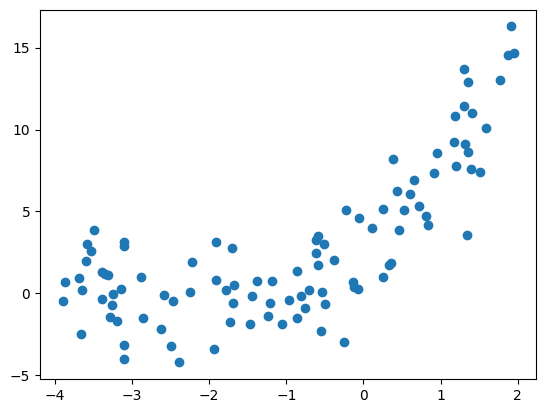

In [144]:
plt.scatter(x, y)
plt.show()

### 线性回归和多项式回归

In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

Degree: 1 Score: 0.5273556058762796
Degree: 2 Score: 0.7961121480231473
Degree: 5 Score: 0.8021247301740011
Degree: 20 Score: 0.1499917289794862


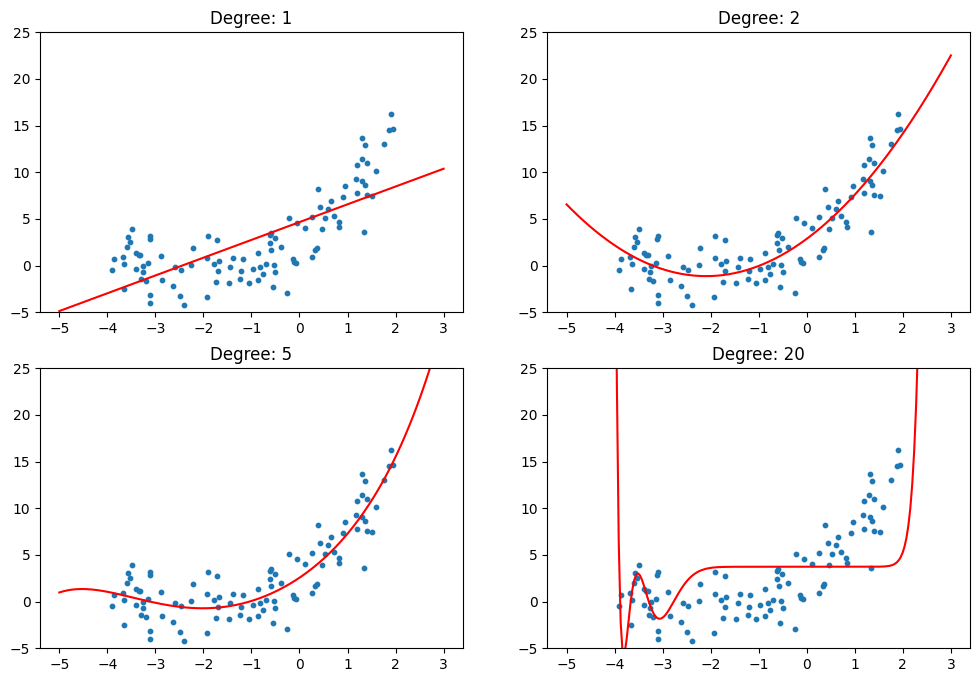

In [146]:
plt.figure(figsize=(12, 8))  # 设置当前图形大小
degrees = [1, 2, 5, 20]  # 设置不同的多项式次数
for i, degree in enumerate(degrees):  # 分别训练并绘制不同次数的多项式回归模型
    polynomial_features = PolynomialFeatures(degree=degree)  # 生成多项式特征
    X_poly = polynomial_features.fit_transform(X)

    linear_regression = LinearRegression()  # 训练线性回归模型
    linear_regression.fit(X_poly, y)

    X_new = np.linspace(-5, 3, 200).reshape(-1, 1)  # 生成用于绘制回归曲线的新数据
    X_new_poly = polynomial_features.fit_transform(X_new)
    y_predict = linear_regression.predict(X_new_poly)

    plt.subplot(2, 2, i + 1)  # 创建子图
    plt.title("Degree: {0}".format(degree))
    plt.scatter(x, y, s=10)  # 绘制原始数据和预测曲线
    plt.ylim(-5, 25)
    plt.plot(X_new, y_predict, color="red")

    print("Degree:", degree, "Score:", linear_regression.score(X_poly, y))  # 输出模型的 R² 得分
plt.show()

### 划分数据集

In [147]:
from sklearn.model_selection import train_test_split

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True)

In [149]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((70, 1), (30, 1), (70,), (30,))

### 绘制学习曲线

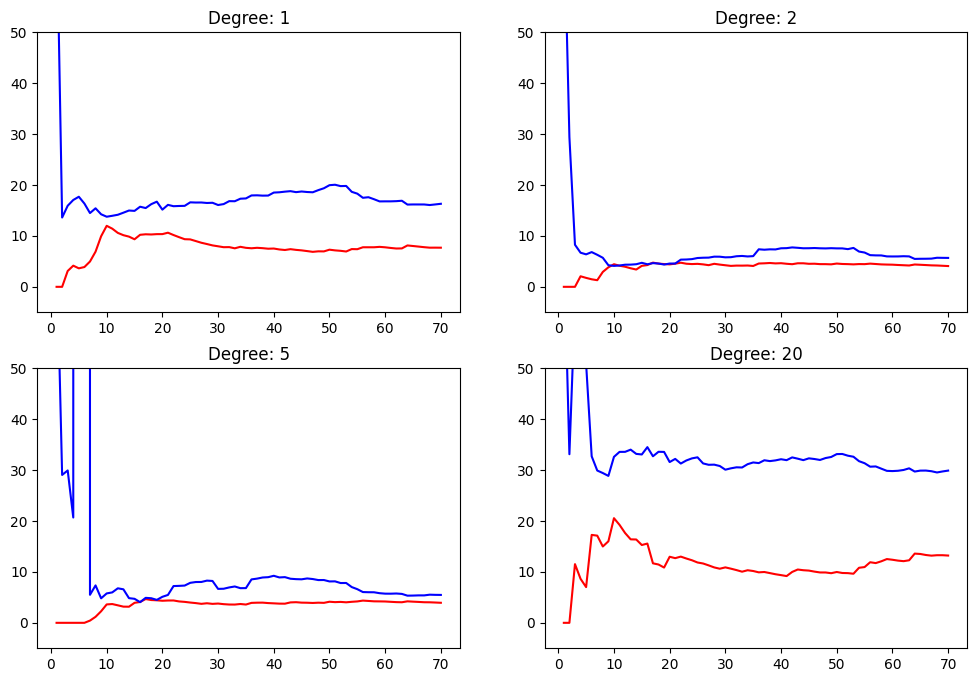

In [150]:
from sklearn.metrics import mean_squared_error
plt.figure(figsize=(12, 8))  # 设置当前图形大小
degrees = [1, 2, 5, 20]  # 设置不同的多项式次数
for i, degree in enumerate(degrees):  # 分别训练并绘制不同次数的多项式回归模型
    polynomial_features = PolynomialFeatures(degree=degree)  # 生成多项式特征
    X_poly_train = polynomial_features.fit_transform(X_train)  # 将训练集和测试集转换为多项式特征
    X_poly_test = polynomial_features.transform(X_test)

    train_error, test_error = [], []  # 保存训练误差和测试误差
    for k in range(len(X_train)):  # 逐渐增加训练样本数量
        linear_regression = LinearRegression()  # 训练线性回归模型
        linear_regression.fit(X_poly_train[: k+1], y_train[: k+1])

        y_train_pred = linear_regression.predict(X_poly_train[: k + 1])  # 计算训练集 MSE
        train_error.append(mean_squared_error(y_train[: k + 1], y_train_pred))

        y_test_pred = linear_regression.predict(X_poly_test)  # 计算测试集 MSE
        test_error.append(mean_squared_error(y_test, y_test_pred))

    plt.subplot(2, 2, i + 1)  # 创建子图
    plt.title("Degree: {0}".format(degree))
    plt.ylim(-5, 50)
    plt.plot([k + 1 for k in range(len(X_train))], train_error, color="red", label="Train")
    plt.plot([k + 1 for k in range(len(X_train))], test_error, color="blue", label="Test")
plt.show()

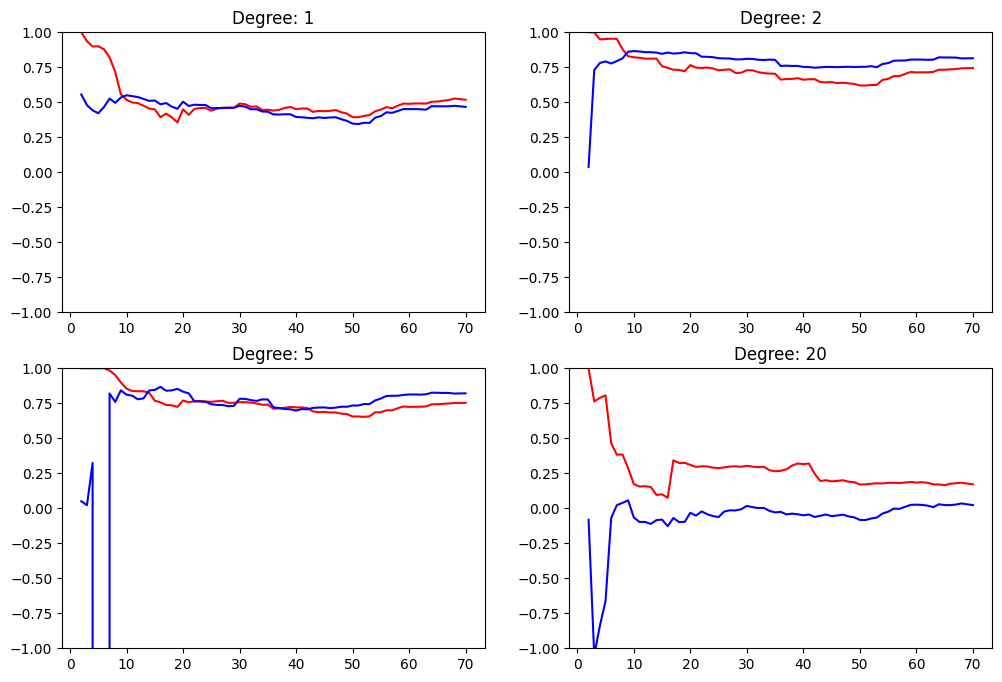

In [151]:
plt.figure(figsize=(12, 8))  # 设置当前图形大小
degrees = [1, 2, 5, 20]  # 设置不同的多项式次数
for i, degree in enumerate(degrees):  # 分别训练并绘制不同次数的多项式回归模型
    polynomial_features = PolynomialFeatures(degree=degree)  # 生成多项式特征
    X_poly_train = polynomial_features.fit_transform(X_train)  # 将训练集和测试集转换为多项式特征
    X_poly_test = polynomial_features.transform(X_test)

    train_score, test_score = [], []  # 保存训练集和测试集的 R² 得分
    for k in range(1, len(X_train)):  # 逐渐增加训练样本数量
        linear_regression = LinearRegression()  # 训练线性回归模型
        linear_regression.fit(X_poly_train[: k+1], y_train[: k+1])

        train_score.append(linear_regression.score(X_poly_train[: k + 1], y_train[: k + 1]))  # 计算训练集 R² 得分
        test_score.append(linear_regression.score(X_poly_test, y_test))  # 计算测试集 R² 得分

    plt.subplot(2, 2, i + 1)  # 创建子图
    plt.title("Degree: {0}".format(degree))
    plt.ylim(-1, 1)
    plt.plot([k + 1 for k in range(1, len(X_train))], train_score, color="red", label="Train")
    plt.plot([k + 1 for k in range(1, len(X_train))], test_score, color="blue", label="Test")
plt.show()